<a href="https://colab.research.google.com/github/inginierojuan/estructurajuan/blob/main/Copia_de_Te_damos_la_bienvenida_a_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ Proyecto de Turismo
## Sistema de Recomendación y Predicción Turística – Colombia

---
**Curso:** Inteligencia Artificial – Nivel Básico | Talento Tech  
**Módulos:** 2, 3 y 4  
**Equipo:** *(nombre del equipo)*  
**Integrantes:** *(nombres y roles)*

---

### 🎯 Objetivos del proyecto
1. **Predecir el gasto total** del viajero en USD (regresión)
2. **Predecir si el viajero recomendaría el destino** (clasificación binaria)
3. **Segmentar perfiles de viajero** con clustering (K-Means)

### 📋 Variables del dataset
| Variable | Descripción | Tipo |
|---|---|---|
| `destino` | Ciudad o región visitada en Colombia | Categórica |
| `origen_viajero` | Nacional o internacional | Categórica |
| `mes_viaje` | Mes del año (1–12) | Numérica |
| `temporada` | Trimestre del año (Q1–Q4) | Categórica |
| `duracion_noches` | Noches de pernoctación | Numérica |
| `num_acompanantes` | Personas que viajan juntas | Numérica |
| `edad_viajero` | Edad del viajero principal | Numérica |
| `motivo_viaje` | Motivo (vacaciones, negocios, aventura, etc.) | Categórica |
| `tipo_alojamiento` | Tipo de hospedaje usado | Categórica |
| `medio_transporte` | Cómo llegó al destino | Categórica |
| `gasto_total_usd` | **TARGET regresión** – Gasto total en USD | Numérica |
| `satisfaccion_1_5` | Satisfacción del viajero (1 al 5) | Numérica |
| `recomendaria` | **TARGET clasificación** – ¿Recomendaría el destino? (0/1) | Binaria |


---
## 📦 CELDA 1 – Librerías
> ▶️ Ejecuta primero.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, r2_score, accuracy_score,
    classification_report, confusion_matrix, silhouette_score
)
import pickle

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Librerías cargadas')

✅ Librerías cargadas


---
## 📂 CELDA 2 – Carga del Dataset
> ⚠️ Sube `/turismo_golfo.csv` al panel de archivos de Colab.

In [44]:
import pandas as pd
df = pd.read_csv('/content/turismo_golfo.csv')
print(f'✅ Dataset cargado: {df.shape[0]} filas | {df.shape[1]} columnas')
df.head(10)

✅ Dataset cargado: 350 filas | 13 columnas


,destino,origen_viajero,mes_viaje,temporada,duracion_noches,num_acompanantes,edad_viajero,motivo_viaje,tipo_alojamiento,medio_transporte,gasto_total_usd,satisfaccion_1_5,recomendaria
0,Tolu,nacional,11,Q4,12,2,33,descanso,hostal,maritimo,325,3,1
1,Tolu,nacional,7,Q3,2,1,32,negocios,glamping,terrestre,80,3,1
2,San_Bernardo_del_Viento,internacional,11,Q4,4,3,55,aventura,hotel,terrestre,192,5,1
3,Tolu,nacional,6,Q2,7,0,40,aventura,glamping,aereo,214,5,1
4,San_Bernardo_del_Viento,nacional,9,Q3,2,4,36,ecoturismo,glamping,aereo,80,4,1
5,Covenas,nacional,5,Q2,14,0,42,aventura,airbnb,maritimo,657,3,1
6,San_Antero,nacional,6,Q2,12,5,59,vacaciones,glamping,maritimo,383,4,1
7,Covenas,internacional,5,Q2,11,2,67,vacaciones,hostal,terrestre,487,4,1
8,San_Antero,nacional,2,Q1,4,5,49,cultura,finca,aereo,132,4,1
9,San_Bernardo_del_Viento,internacional,5,Q2,10,3,41,descanso,hostal,maritimo,597,3,1


In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 🔍 CELDA 3 – Exploración de Datos

In [46]:
print('📊 INFORMACIÓN GENERAL')
df.info()
print('\n📈 ESTADÍSTICAS DESCRIPTIVAS')
display(df.describe().round(2))
print('\n❓ VALORES NULOS:', df.isnull().sum().sum())
for col in ['destino','origen_viajero','motivo_viaje','tipo_alojamiento','medio_transporte']:
    print(f'\n{col}:\n{df[col].value_counts().to_string()}')

📊 INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   destino           350 non-null    object
 1   origen_viajero    350 non-null    object
 2   mes_viaje         350 non-null    int64 
 3   temporada         350 non-null    object
 4   duracion_noches   350 non-null    int64 
 5   num_acompanantes  350 non-null    int64 
 6   edad_viajero      350 non-null    int64 
 7   motivo_viaje      350 non-null    object
 8   tipo_alojamiento  350 non-null    object
 9   medio_transporte  350 non-null    object
 10  gasto_total_usd   350 non-null    int64 
 11  satisfaccion_1_5  350 non-null    int64 
 12  recomendaria      350 non-null    int64 
dtypes: int64(7), object(6)
memory usage: 35.7+ KB

📈 ESTADÍSTICAS DESCRIPTIVAS


,mes_viaje,duracion_noches,num_acompanantes,edad_viajero,gasto_total_usd,satisfaccion_1_5,recomendaria
count,350.00,350.00,350.00,350.00,350.00,350.00,350.00
mean,6.66,7.31,2.49,44.25,320.71,4.05,0.94
std,3.44,4.06,1.64,15.44,196.61,0.89,0.23
min,1.00,1.00,0.00,18.00,80.00,1.00,0.00
25%,4.00,4.00,1.00,31.00,144.50,4.00,1.00
50%,7.00,7.00,2.00,44.00,289.50,4.00,1.00
75%,10.00,11.00,4.00,58.00,464.75,5.00,1.00
max,12.00,14.00,5.00,70.00,900.00,5.00,1.00



❓ VALORES NULOS: 0

destino:
destino
San_Antero                 94
Covenas                    92
San_Bernardo_del_Viento    84
Tolu                       80

origen_viajero:
origen_viajero
nacional         248
internacional    102

motivo_viaje:
motivo_viaje
vacaciones    66
aventura      60
cultura       60
negocios      57
ecoturismo    55
descanso      52

tipo_alojamiento:
tipo_alojamiento
glamping    66
hotel       65
cabanas     58
airbnb      55
hostal      54
finca       52

medio_transporte:
medio_transporte
maritimo     125
terrestre    119
aereo        106


### ✏️ Observaciones
- **¿Cuál es el destino más visitado?** ...
- **¿Cuál es el gasto promedio de un viajero?** ...
- **¿Qué porcentaje de viajeros recomendaría el destino?** ...

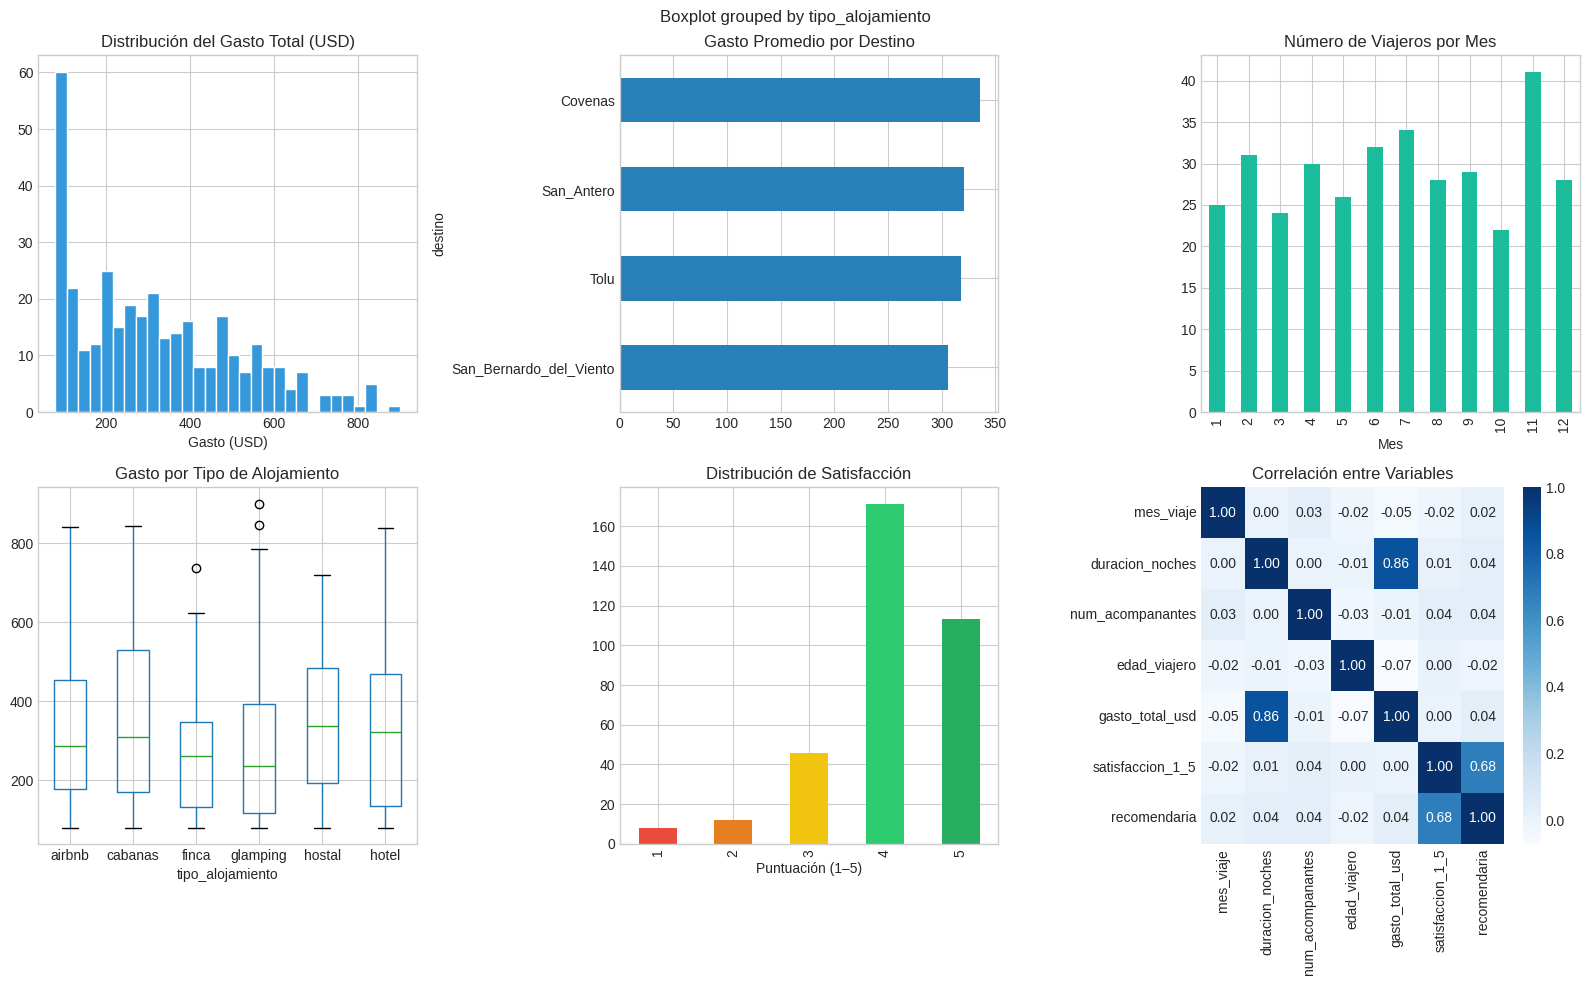

✅ Gráficas guardadas


In [47]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Análisis Exploratorio – Turismo Colombia', fontsize=15, fontweight='bold')

# 1. Distribución gasto
axes[0,0].hist(df['gasto_total_usd'], bins=30, color='#3498db', edgecolor='white')
axes[0,0].set_title('Distribución del Gasto Total (USD)')
axes[0,0].set_xlabel('Gasto (USD)')

# 2. Gasto por destino
df.groupby('destino')['gasto_total_usd'].mean().sort_values().plot(
    kind='barh', ax=axes[0,1], color='#2980b9')
axes[0,1].set_title('Gasto Promedio por Destino')

# 3. Viajeros por mes
df['mes_viaje'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,2], color='#1abc9c')
axes[0,2].set_title('Número de Viajeros por Mes')
axes[0,2].set_xlabel('Mes')

# 4. Gasto por alojamiento
df.boxplot(column='gasto_total_usd', by='tipo_alojamiento', ax=axes[1,0])
axes[1,0].set_title('Gasto por Tipo de Alojamiento')

# 5. Satisfacción – distribución
df['satisfaccion_1_5'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,1], color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
axes[1,1].set_title('Distribución de Satisfacción')
axes[1,1].set_xlabel('Puntuación (1–5)')

# 6. Correlación
numericas = df.select_dtypes(include=[np.number])
sns.heatmap(numericas.corr(), annot=True, fmt='.2f', cmap='Blues', ax=axes[1,2])
axes[1,2].set_title('Correlación entre Variables')

plt.tight_layout()
plt.savefig('visualizaciones_turismo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráficas guardadas')

---
## ⚙️ CELDA 5 – Preprocesamiento

In [48]:
df_m = df.copy()
le = LabelEncoder()

cat_cols = ['destino','origen_viajero','temporada','motivo_viaje','tipo_alojamiento','medio_transporte']
for col in cat_cols:
    df_m[col+'_cod'] = le.fit_transform(df_m[col].astype(str))
    print(f'  {col}: {df_m[col].nunique()} categorías')

features = ['origen_viajero_cod','mes_viaje','duracion_noches','num_acompanantes',
            'edad_viajero','motivo_viaje_cod','tipo_alojamiento_cod','medio_transporte_cod',
            'destino_cod']

X_reg = df_m[features];  y_reg = df_m['gasto_total_usd']
X_clf = df_m[features];  y_clf = df_m['recomendaria']
X_clu = df_m[features]

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_r_sc = scaler.fit_transform(X_tr_r);  X_te_r_sc = scaler.transform(X_te_r)
X_tr_c_sc = scaler.fit_transform(X_tr_c);  X_te_c_sc = scaler.transform(X_te_c)
X_clu_sc  = scaler.fit_transform(X_clu)

print(f'\n✅ Listo | Train: {X_tr_r.shape[0]} | Test: {X_te_r.shape[0]}')

  destino: 4 categorías
  origen_viajero: 2 categorías
  temporada: 4 categorías
  motivo_viaje: 6 categorías
  tipo_alojamiento: 6 categorías
  medio_transporte: 3 categorías

✅ Listo | Train: 280 | Test: 70


---
## 🤖 CELDA 6 – Regresión: Predicción del Gasto

In [49]:
modelos_reg = {
    'Regresión Lineal': LinearRegression(),
    'Random Forest':    RandomForestRegressor(n_estimators=100, random_state=42),
}
for nombre, modelo in modelos_reg.items():
    modelo.fit(X_tr_r_sc, y_tr_r)
    pred = modelo.predict(X_te_r_sc)
    mae  = mean_absolute_error(y_te_r, pred)
    r2   = r2_score(y_te_r, pred)
    print(f'\n📌 {nombre}')
    print(f'   MAE: ${mae:.2f} USD  |  R²: {r2:.3f}')

modelo_gasto = modelos_reg['Random Forest']


📌 Regresión Lineal
   MAE: $86.64 USD  |  R²: 0.751

📌 Random Forest
   MAE: $89.24 USD  |  R²: 0.737


---
## 🤖 CELDA 7 – Clasificación: ¿Recomendaría el destino?

,Modelo,Accuracy,CV Score
0,Regresión Logística,0.929,0.946
1,Árbol de Decisión,0.914,0.925
2,Random Forest,0.929,0.946


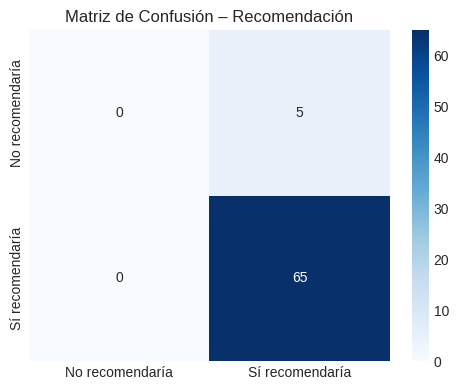

                 precision    recall  f1-score   support

No recomendaría       0.00      0.00      0.00         5
Sí recomendaría       0.93      1.00      0.96        65

       accuracy                           0.93        70
      macro avg       0.46      0.50      0.48        70
   weighted avg       0.86      0.93      0.89        70



In [50]:
modelos_clf = {
    'Regresión Logística': LogisticRegression(max_iter=300),
    'Árbol de Decisión':   DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}
res_clf = []
mejores_c = {}
for nombre, modelo in modelos_clf.items():
    modelo.fit(X_tr_c_sc, y_tr_c)
    pred = modelo.predict(X_te_c_sc)
    acc  = accuracy_score(y_te_c, pred)
    cv   = cross_val_score(modelo, X_tr_c_sc, y_tr_c, cv=5).mean()
    res_clf.append({'Modelo': nombre, 'Accuracy': round(acc,3), 'CV Score': round(cv,3)})
    mejores_c[nombre] = modelo

display(pd.DataFrame(res_clf))

# Matriz de confusión
best_clf = mejores_c['Random Forest']
pred_best = best_clf.predict(X_te_c_sc)
fig, ax = plt.subplots(figsize=(5,4))
cm = confusion_matrix(y_te_c, pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No recomendaría','Sí recomendaría'],
            yticklabels=['No recomendaría','Sí recomendaría'], ax=ax)
ax.set_title('Matriz de Confusión – Recomendación')
plt.tight_layout(); plt.show()
print(classification_report(y_te_c, pred_best,
      target_names=['No recomendaría','Sí recomendaría']))

---
## 🔵 CELDA 8 – Clustering: Segmentación de Perfiles de Viajero
> 💡 Esta celda implementa aprendizaje NO supervisado (Módulo 3)

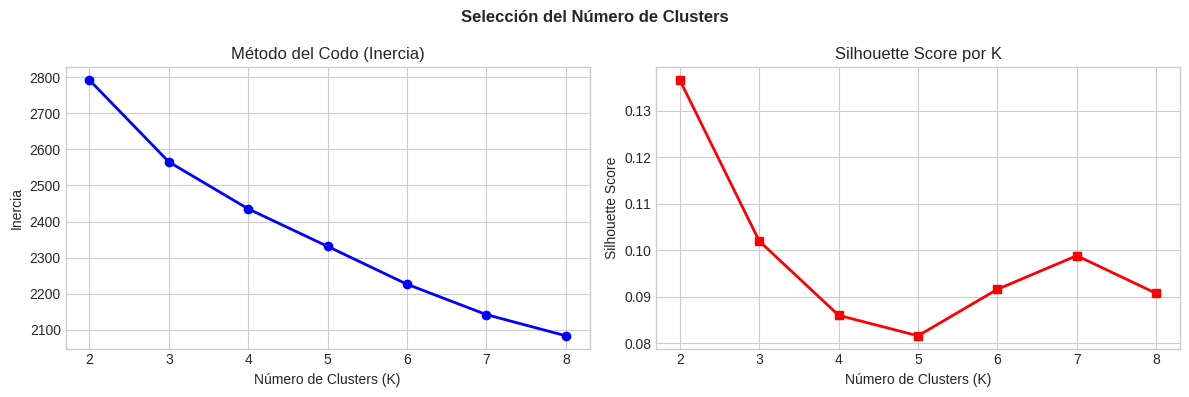


💡 K recomendado por Silhouette Score: 2


In [51]:
# Método del codo para elegir K
inercias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clu_sc)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clu_sc, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inercias, 'bo-', linewidth=2)
axes[0].set_title('Método del Codo (Inercia)')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')

axes[1].plot(K_range, silhouettes, 'rs-', linewidth=2)
axes[1].set_title('Silhouette Score por K')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Selección del Número de Clusters', fontweight='bold')
plt.tight_layout()
plt.show()

mejor_k = K_range[np.argmax(silhouettes)]
print(f'\n💡 K recomendado por Silhouette Score: {mejor_k}')

In [52]:
# Aplicar K-Means con el K elegido
K_ELEGIDO = 3  # 👈 MODIFICA este valor según el resultado del gráfico anterior

kmeans = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_clu_sc)

print(f'✅ K-Means aplicado con K={K_ELEGIDO}')
print(f'Silhouette Score: {silhouette_score(X_clu_sc, df["cluster"]):.3f}')
print('\n📊 PERFIL PROMEDIO POR CLUSTER:')
perfil = df.groupby('cluster')[['duracion_noches','num_acompanantes',
                                 'edad_viajero','gasto_total_usd','satisfaccion_1_5']].mean()
display(perfil.round(1))

print('\n📍 Destinos más frecuentes por cluster:')
for c in range(K_ELEGIDO):
    top3 = df[df['cluster']==c]['destino'].value_counts().head(3)
    print(f'  Cluster {c}: {list(top3.index)}')

✅ K-Means aplicado con K=3
Silhouette Score: 0.102

📊 PERFIL PROMEDIO POR CLUSTER:


,duracion_noches,num_acompanantes,edad_viajero,gasto_total_usd,satisfaccion_1_5
cluster,,,,,
0,5.0,2.7,41.4,230.2,4.0
1,9.9,2.1,46.6,407.5,4.1
2,7.0,2.6,44.9,326.9,4.0



📍 Destinos más frecuentes por cluster:
  Cluster 0: ['Tolu', 'San_Bernardo_del_Viento', 'San_Antero']
  Cluster 1: ['Covenas', 'San_Antero', 'San_Bernardo_del_Viento']
  Cluster 2: ['San_Antero', 'Covenas', 'San_Bernardo_del_Viento']


### ✏️ Interpretación de los Clusters
*Describe con tus palabras el perfil de cada cluster (ej: «turista internacional de alto gasto», «viajero nacional familiar», etc.):*

- **Cluster 0:** ...
- **Cluster 1:** ...
- **Cluster 2:** ...